# Connecting USGS Pesticide Observations to NWAA Data Companion Hydrology (Pilot)

**Purpose.** Attach monthly modeled hydrology from the USGS National Water Availability Assessment (NWAA)
Data Companion (DC) to every pesticide observation at three pilot stations, so the same workflow can later be
applied to all national sites.

**Pilot stations**

| USGS station | Name | State |
|---|---|---|
| 06800000 | Maple Creek | NE |
| 05451210 | South Fork Iowa River | IA |
| 02091500 | Contentnea Creek | NC |

**DC product and variables.** `wqn-nhmprms-conus-nwaa-v1` (NHM-PRMS, monthly, by HUC12, 1983-01 to 2021-09):

| DC variable | Meaning | Unit |
|---|---|---|
| `incqkflow` | Incremental quickflow: fast storm runoff generated inside a HUC12 | mm/month |
| `incbsflow` | Incremental baseflow: slow groundwater contribution generated inside a HUC12 | mm/month |
| `soilmstfr` | Soil moisture fraction: how full the soil is (0 = dry, 1 = saturated) | fraction |

**Time window.** January 2013 – August 2021 (104 months), the overlap window in the task brief.
2013 through 2020: 8 full years × 12 = 96 months;
January to August 2021: 8 months;
Total: 96 + 8 = 104 months

**Workflow (one station)**

```
USGS station  ->  NLDI upstream basin polygon  ->  HUC12s inside the basin (+ area) ->  DC monthly values for those HUC12s  ->  one basin value per month ->  join to pesticide samples by (station, year-month)
```

**Important distinctions**
- DC values are **modeled** (simulated by NHM-PRMS), not measured. They are kept in separate `dc_*` columns and
  never overwrite the observed environmental variables.
- DC values are **monthly**; pesticide samples are taken on specific days. Every sample in a month receives the
  same monthly DC values (monthly upstream-basin hydrologic context).

**Notebook sections**
1. Setup (Google Drive, API key)
2. Upstream basins from NLDI
3. HUC12 boundary layer (Oct-2020 WBD)
4. Maple Creek (06800000): HUC12 selection → DC extraction → basin-month values → join
5. South Fork Iowa River (05451210)
6. Contentnea Creek (02091500)
7. Summary, known issues, next steps

## 1. Setup

**Inputs expected in Google Drive** – data directory, stored in the GitHub repository:

| File | Source |
|---|---|
| `102020_wbd_hu12.gpkg` | October-2020 Watershed Boundary Dataset HUC12 polygons (source:https://www.sciencebase.gov/catalog/item/67082a0fd34e969edc5a1cca), the version the DC is mapped to |
| `t2_pest_concs_enriched_v2.parquet` | Project pesticide dataset (84 analytes, national sites) – private project data |
| `combined_wqn-nhmprms-conus-nwaa-v1_CONUS_198301-202109_long.csv` | source: https://water.usgs.gov/nwaa-data/data/water-quantity/wqn-nhmprms-conus-nwaa-v1/wqn-nhmprms-conus-nwaa-v1_README.html) |

**API key.** A USGS API key is optional (it raises rate limits). Never type the key into a notebook cell:
store it in Colab **Secrets** (key icon in the left sidebar) under the name `USGS_API_KEY`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')   # approve the sign-in popup

Mounted at /content/drive


In [2]:
# Load the USGS API key from Colab Secrets (never hard-code keys in the notebook)
import os
try:
    from google.colab import userdata
    os.environ["USGS_API_KEY"] = userdata.get("USGS_API_KEY")
    print("USGS API key loaded from Colab Secrets.")
except Exception:
    from getpass import getpass
    os.environ["USGS_API_KEY"] = getpass("USGS API key (press Enter to skip): ")

USGS API key (press Enter to skip): ··········


## 2. Upstream basins from NLDI

The **Network-Linked Data Index (NLDI)** follows the national river network (NHDPlus) upstream from a USGS
station and returns one polygon: all land that drains to that station (its drainage area). Rain falling inside
the polygon eventually flows past the station; rain falling outside does not.

Endpoint: `https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-<station>/basin`

The first cell tests one station; the second downloads all three pilot basins.

In [3]:
import requests
import json
import os

station = "05451210"

url = (
    "https://api.water.usgs.gov/nldi/linked-data/"
    f"nwissite/USGS-{station}/basin"
)

params = {
    "f": "json"
}

response = requests.get(url, params=params, timeout=120)
response.raise_for_status()

basin = response.json()

print("HTTP status:", response.status_code)
print("GeoJSON type:", basin.get("type"))
print("Number of features:", len(basin.get("features", [])))

# Create the directory if it doesn't exist
os.makedirs("data/raw", exist_ok=True)

with open(f"data/raw/{station}_basin.geojson", "w") as f:
    json.dump(basin, f, indent=2)

print("Saved basin.")

HTTP status: 200
GeoJSON type: FeatureCollection
Number of features: 1
Saved basin.


In [4]:
import requests
import json
import os

stations = {
    "05451210": "South Fork Iowa River",
    "06800000": "Maple Creek",
    "02091500": "Contentnea Creek",
}

os.makedirs("data/raw/basins", exist_ok=True)

base_url = (
    "https://api.water.usgs.gov/nldi/linked-data/"
    "nwissite/USGS-{station}/basin"
)

for station, name in stations.items():

    print(f"\nProcessing {station}: {name}")

    url = base_url.format(station=station)

    response = requests.get(
        url,
        params={"f": "json"},
        timeout=120
    )

    response.raise_for_status()

    basin = response.json()

    n_features = len(basin.get("features", []))

    print("Features:", n_features)

    output = f"data/raw/basins/{station}_basin.geojson"

    with open(output, "w") as f:
        json.dump(basin, f, indent=2)

    print("Saved:", output)


Processing 05451210: South Fork Iowa River
Features: 1
Saved: data/raw/basins/05451210_basin.geojson

Processing 06800000: Maple Creek
Features: 1
Saved: data/raw/basins/06800000_basin.geojson

Processing 02091500: Contentnea Creek
Features: 1
Saved: data/raw/basins/02091500_basin.geojson


Quick visual check of each basin polygon (shape and CRS). Basin area is checked later against the official
USGS drainage area: a ratio close to 1.00 confirms the station snapped to the correct river.

                                            geometry
0  POLYGON ((-93.21165 42.29943, -93.24064 42.306...
CRS: EPSG:4326


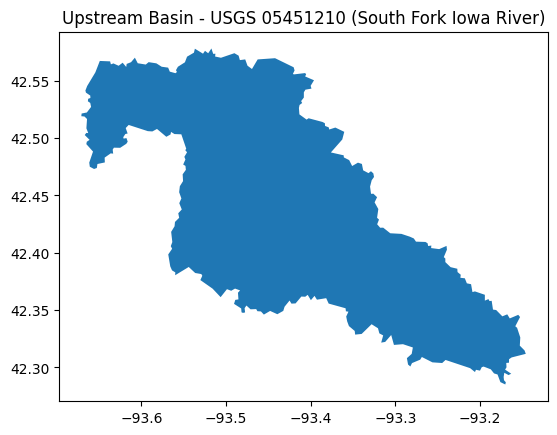

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

basin = gpd.read_file(
    "/content/data/raw/basins/05451210_basin.geojson"
)

print(basin)
print("CRS:", basin.crs)

basin.plot()

plt.title("Upstream Basin - USGS 05451210 (South Fork Iowa River)")
plt.show()

                                            geometry
0  POLYGON ((-77.58324 35.42936, -77.58119 35.430...
CRS: EPSG:4326


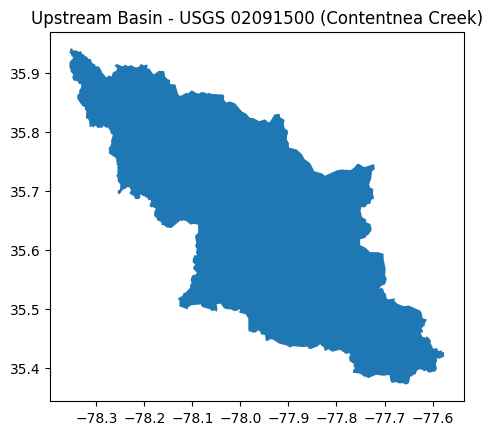

In [6]:
basin = gpd.read_file(
    "/content/data/raw/basins/02091500_basin.geojson"
)

print(basin)
print("CRS:", basin.crs)

basin.plot()

plt.title("Upstream Basin - USGS 02091500 (Contentnea Creek)")
plt.show()

                                            geometry
0  POLYGON ((-96.69999 41.54382, -96.70974 41.547...
CRS: EPSG:4326


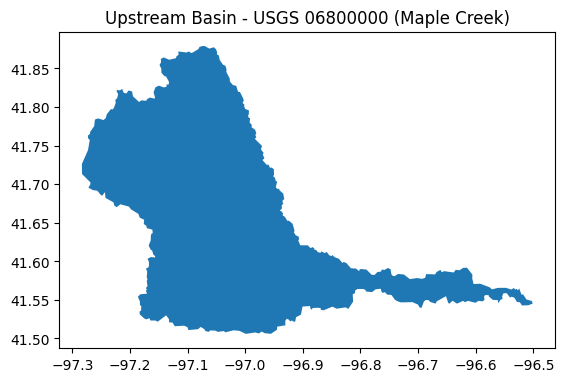

In [7]:
basin = gpd.read_file(
    "/content/data/raw/basins/06800000_basin.geojson"
)

print(basin)
print("CRS:", basin.crs)

basin.plot()

plt.title("Upstream Basin - USGS 06800000 (Maple Creek)")
plt.show()

## 3. HUC12 boundary layer

**HUC12s** (12-digit Hydrologic Unit Codes) are small, fixed watershed units (~50–150 km²) that USGS mapped
across the whole country. They are map areas, not monitoring stations. The DC publishes its values per HUC12,
so we need to know which HUC12s make up each station's basin.

We use the **October 2020** WBD, the version the DC is mapped to (87,020 CONUS HUC12s).

In [8]:
import geopandas as gpd

huc12 = gpd.read_file(
    "/content/drive/MyDrive/Datasets/102020_wbd_hu12.gpkg"
)

print("Rows:", len(huc12))
print("CRS:", huc12.crs)
print("Columns:")
print(huc12.columns.tolist())

huc12.head()

Rows: 101722
CRS: EPSG:4269
Columns:
['METASOURCEID', 'SOURCEDATADESC', 'SOURCEORIGINATOR', 'SOURCEFEATUREID', 'LOADDATE', 'GNIS_ID', 'AREAACRES', 'AREASQKM', 'STATES', 'HUC12', 'NAME', 'HUTYPE', 'HUMOD', 'TOHUC', 'NONCONTRIBUTINGAREAACRES', 'NONCONTRIBUTINGAREASQKM', 'geometry']


,METASOURCEID,SOURCEDATADESC,SOURCEORIGINATOR,SOURCEFEATUREID,LOADDATE,GNIS_ID,AREAACRES,AREASQKM,STATES,HUC12,NAME,HUTYPE,HUMOD,TOHUC,NONCONTRIBUTINGAREAACRES,NONCONTRIBUTINGAREASQKM,geometry
0,{CCF566C5-F081-4C07-A802-25CF3BCA1264},None,None,None,2015-10-02 08:35:04+00:00,NaN,17565.66,71.09,ME,010100020101,Smith Brook,S,NM,010100020105,NaN,NaN,"MULTIPOLYGON (((-69.21016 46.35968, -69.20992 ..."
1,{CCF566C5-F081-4C07-A802-25CF3BCA1264},None,None,None,2015-10-02 08:30:45+00:00,NaN,20053.75,81.15,ME,010100020102,Russell Brook,S,NM,010100020105,NaN,NaN,"MULTIPOLYGON (((-69.5794 46.44288, -69.57919 4..."
2,{CCF566C5-F081-4C07-A802-25CF3BCA1264},None,None,None,2015-10-02 08:35:04+00:00,NaN,18630.05,75.39,ME,010100020103,Soper Brook,S,NM,010100020105,NaN,NaN,"MULTIPOLYGON (((-69.21016 46.35968, -69.21015 ..."
3,{CCF566C5-F081-4C07-A802-25CF3BCA1264},None,None,None,2015-10-02 08:29:54+00:00,NaN,14247.13,57.66,ME,010100020104,Snare Brook,S,NM,010100020105,NaN,NaN,"MULTIPOLYGON (((-69.51129 46.47166, -69.51114 ..."
4,{CCF566C5-F081-4C07-A802-25CF3BCA1264},None,None,None,2016-04-12 15:54:21+00:00,NaN,37714.37,152.62,ME,010100020105,Woodman Brook-Eagle Lake,S,RS,010100020204,NaN,NaN,"MULTIPOLYGON (((-69.35971 46.42225, -69.3592 4..."


## 4. Maple Creek (USGS 06800000)

### 4.1 Select the HUC12s inside the basin
1. Load only Nebraska HUC12s (faster than loading all 87,020).
2. Put the basin and HUC12s in the same coordinate system.
3. Find HUC12s that intersect the basin.
4. Measure how much of each HUC12 lies inside the basin, in an equal-area projection (EPSG:5070).

In [ ]:
import geopandas as gpd

huc_path = "/content/drive/MyDrive/Datasets/102020_wbd_hu12.gpkg"

# Read ONLY Nebraska HUC12 polygons directly from the GPKG
huc_ne = gpd.read_file(
    huc_path,
    where="STATES = 'NE'"
)

print("HUC12 polygons loaded:", len(huc_ne))
print("CRS:", huc_ne.crs)

print(
    huc_ne[
        ["HUC12", "NAME", "AREASQKM", "STATES"]
    ].head()
)

HUC12 polygons loaded: 1832
CRS: EPSG:4269
          HUC12                   NAME  AREASQKM STATES
0  101201080201         Sowbelly Creek    113.98     NE
1  101201080202        Warbonnet Creek    122.43     NE
2  101201080203  Boggy Creek-Hat Creek    129.53     NE
3  101201080204            Squaw Creek     88.37     NE
4  101201080205              Jim Creek     93.76     NE


In [ ]:
basin = gpd.read_file(
    "/content/drive/MyDrive/Datasets/06800000_basin.geojson"
)

print("Basin CRS:", basin.crs)
print("HUC CRS:", huc_ne.crs)

Basin CRS: EPSG:4326
HUC CRS: EPSG:4269


In [ ]:
# Convert the Nebraska HUC12 subset to the basin CRS
huc_ne = huc_ne.to_crs(basin.crs)

print("Basin CRS:", basin.crs)
print("HUC CRS:", huc_ne.crs)

Basin CRS: EPSG:4326
HUC CRS: EPSG:4326


In [ ]:
# Combine the upstream basin geometry
basin_geom = basin.geometry.union_all()

# Find HUC12 polygons that intersect the basin
selected = huc_ne[
    huc_ne.intersects(basin_geom)
].copy()

print("Number of intersecting HUC12s:", len(selected))

print(
    selected[
        ["HUC12", "NAME", "AREASQKM", "STATES"]
    ].sort_values("HUC12").to_string(index=False)
)

Number of intersecting HUC12s: 24
       HUC12                             NAME  AREASQKM STATES
102002010101                  St Pauls Church     67.80     NE
102002010208                     Taylor Creek     42.64     NE
102002010209         Brewery Hill-Shell Creek    115.33     NE
102002020101       Rawhide Creek-Platte River    311.47     NE
102200030106                   Meridian Creek    153.58     NE
102200030202                  Butterfly Creek     74.12     NE
102200030204                      Cedar Creek     46.93     NE
102200030205  Maskenthine Creek-Elkhorn River    115.52     NE
102200030403                       Rock Creek    104.64     NE
102200030501 Headwaters West Fork Maple Creek    103.57     NE
102200030502      Upper West Fork Maple Creek     76.31     NE
102200030503     Middle West Fork Maple Creek    150.68     NE
102200030504             South Fork Dry Creek     56.92     NE
102200030505                        Dry Creek     87.83     NE
102200030506      Low

Area of each HUC12 inside the basin (`intersection_km2`) and the share of the HUC12 that is inside (`overlap_pct`):

In [ ]:
import geopandas as gpd

# --------------------------------------------------
# Project ONLY the small selected dataset
#    and basin to an area-preserving CRS
# --------------------------------------------------

basin_5070 = basin.to_crs("EPSG:5070")
selected_5070 = selected.to_crs("EPSG:5070")

# One combined upstream-basin geometry
basin_geom_5070 = basin_5070.geometry.union_all()


# --------------------------------------------------
# Calculate intersection area for each HUC12
# --------------------------------------------------

selected_5070["intersection_km2"] = (
    selected_5070.geometry
    .intersection(basin_geom_5070)
    .area
    / 1_000_000
)


# --------------------------------------------------
# 3. Calculate percentage of each HUC12
#    that lies inside the upstream basin
# --------------------------------------------------

selected_5070["overlap_pct"] = (
    selected_5070["intersection_km2"]
    / selected_5070["AREASQKM"]
    * 100
)


# --------------------------------------------------
# 4. Display results
# --------------------------------------------------

result = selected_5070[
    [
        "HUC12",
        "NAME",
        "AREASQKM",
        "intersection_km2",
        "overlap_pct"
    ]
].copy()

result = result.sort_values(
    "overlap_pct",
    ascending=False
)

print(
    result.to_string(
        index=False,
        formatters={
            "AREASQKM": "{:.2f}".format,
            "intersection_km2": "{:.2f}".format,
            "overlap_pct": "{:.2f}".format
        }
    )
)

       HUC12                             NAME AREASQKM intersection_km2 overlap_pct
102200030503     Middle West Fork Maple Creek   150.68           150.68      100.00
102200030602     Outlet East Fork Maple Creek   133.23           133.12       99.92
102200030505                        Dry Creek    87.83            87.71       99.86
102200030502      Upper West Fork Maple Creek    76.31            76.13       99.77
102200030601 Headwaters East Fork Maple Creek   148.13           147.77       99.76
102200030504             South Fork Dry Creek    56.92            56.76       99.73
102200030501 Headwaters West Fork Maple Creek   103.57           103.20       99.64
102200030506      Lower West Fork Maple Creek    66.92            66.61       99.53
102200030603        Crystal Creek-Maple Creek    62.96            62.61       99.44
102200030604    City of Nickerson-Maple Creek   137.48            75.23       54.72
102200030202                  Butterfly Creek    74.12             0.26     

In [ ]:
import os

result["station_id"] = "06800000"
result["station_name"] = "Maple Creek"

os.makedirs("/content/data/intermediate", exist_ok=True)

result.to_csv(
    "/content/data/intermediate/06800000_huc12_crosswalk.csv",
    index=False
)

print("Saved.")

Saved.


### 4.2 Keep HUC12s that really drain to the station

Rule used for Maple Creek: keep HUC12s with **≥ 1 km² inside** the basin.
- 24 HUC12s touch the basin, but 14 overlap by < 1 km² (< 0.4 % of their area). These are edge slivers caused by
  small differences between the NLDI and WBD boundaries, not real drainage.
- 10 HUC12s are kept: 9 are ~99–100 % inside; `102200030604` is ~55 % inside because the station sits part-way
  along it.

In [ ]:
target = result[
    result["intersection_km2"] >= 1
].copy()

print("HUC12s for DC extraction:", len(target))

print(
    target[
        ["HUC12", "NAME", "intersection_km2", "overlap_pct"]
    ].to_string(index=False)
)

HUC12s for DC extraction: 10
       HUC12                             NAME  intersection_km2  overlap_pct
102200030503     Middle West Fork Maple Creek        150.678828    99.999222
102200030602     Outlet East Fork Maple Creek        133.120187    99.917576
102200030505                        Dry Creek         87.709614    99.862933
102200030502      Upper West Fork Maple Creek         76.132689    99.767644
102200030601 Headwaters East Fork Maple Creek        147.772094    99.758384
102200030504             South Fork Dry Creek         56.764754    99.727255
102200030501 Headwaters West Fork Maple Creek        103.198694    99.641493
102200030506      Lower West Fork Maple Creek         66.607813    99.533492
102200030603        Crystal Creek-Maple Creek         62.607070    99.439437
102200030604    City of Nickerson-Maple Creek         75.226049    54.717813


In [ ]:
target['HUC12']

,HUC12
1283,102200030503
1288,102200030602
1285,102200030505
1282,102200030502
1287,102200030601
1284,102200030504
1281,102200030501
1286,102200030506
1289,102200030603
1290,102200030604


### 4.3 Extract the three DC variables for these HUC12s

The combined NHM-PRMS file (5.3 GB, all CONUS HUC12s × 465 months × 8 variables) is streamed in chunks and only
the selected HUC12s, the 2013-01 to 2021-08 window, and the three variables are kept.
Columns are selected **by name** (this file lists `year_month` before `huc12_id`), and HUC12 IDs are kept as
12-character text so leading zeros are not lost.

Expected rows: 10 HUC12s × 104 months = 1,040.

In [ ]:
from pathlib import Path
import pandas as pd

# ============================================================
# NHM-PRMS Data Companion
# Pilot: Maple Creek (USGS 06800000)
# ============================================================

URL = (
    "https://water.usgs.gov/nwaa-data/data/water-quantity/"
    "wqn-nhmprms-conus-nwaa-v1/"
    "combined_wqn-nhmprms-conus-nwaa-v1_CONUS_198301-202109_long.csv"
)

VARS = [
    "incqkflow",
    "incbsflow",
    "soilmstfr"
]

# HUC12s with meaningful overlap with the
# NLDI upstream basin of USGS 06800000
HUC12 = set(
    target["HUC12"]
    .astype(str)
    .str.strip()
    .str.zfill(12)
)

# Professor-specified overlap window
START = "201301"
END = "202108"

OUT = Path("/content/data/interim")
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. Read header only
# ============================================================

header = pd.read_csv(
    URL,
    nrows=0
).columns.tolist()

print("Columns in file:")
print(header)


# ============================================================
# 2. Detect required columns
# ============================================================

HCOL = next(
    c for c in header
    if c.lower().startswith("huc12")
)

YCOL = next(
    c for c in header
    if c.lower() == "year_month"
)

VCOLS = [
    next(
        c for c in header
        if c.split("_")[0] == v
    )
    for v in VARS
]

cols = [HCOL, YCOL] + VCOLS

print("\nKeeping columns:")
print(cols)


# ============================================================
# 3. Stream CSV in chunks
# ============================================================

kept = []
n_scanned = 0
n_kept = 0

for ch in pd.read_csv(
    URL,
    usecols=cols,
    dtype={
        HCOL: str,
        YCOL: str
    },
    chunksize=500_000
):

    n_scanned += len(ch)

    # Standardize HUC12
    ch[HCOL] = (
        ch[HCOL]
        .str.strip()
        .str.zfill(12)
    )

    # Standardize YYYYMM
    ym = (
        ch[YCOL]
        .str.replace(
            r"[^0-9]",
            "",
            regex=True
        )
        .str[:6]
    )

    mask = (
        ch[HCOL].isin(HUC12)
        &
        ym.between(START, END)
    )

    small = ch.loc[mask].copy()

    # Save standardized year_month
    small[YCOL] = ym.loc[mask]

    if not small.empty:
        kept.append(small)
        n_kept += len(small)

    print(
        f"Scanned {n_scanned:,} rows | "
        f"kept {n_kept:,}",
        end="\r"
    )


# ============================================================
# 4. Combine selected records
# ============================================================

if not kept:
    raise RuntimeError(
        "No matching HUC12 records were found."
    )

df = pd.concat(
    kept,
    ignore_index=True
)

df = df.rename(
    columns={
        HCOL: "huc12",
        YCOL: "year_month"
    }
)

df = df[
    ["huc12", "year_month"] + VCOLS
].sort_values(
    ["huc12", "year_month"]
)


# ============================================================
# 5. Save small pilot dataset
# ============================================================

output_file = (
    OUT /
    "nhmprms_maple_creek_huc12_month.csv"
)

df.to_csv(
    output_file,
    index=False
)


# ============================================================
# 6. Validation
# ============================================================

EXPECTED_MONTHS = 104
expected_rows = len(HUC12) * EXPECTED_MONTHS

print("\n\nExtraction complete")
print("---------------------------")
print("Saved:", output_file)
print("Rows:", len(df))
print("Expected rows:", expected_rows)
print("HUC12s found:", df["huc12"].nunique())
print("Months found:", df["year_month"].nunique())

print("\nDate range:")
print(
    df["year_month"].min(),
    "to",
    df["year_month"].max()
)

print("\nRows per HUC12:")
print(
    df.groupby("huc12")
      .size()
      .sort_index()
)

print("\nFirst records:")
print(df.head())

Columns in file:
['year_month', 'huc12_id', 'actet_mm/mo', 'incbsflow_mm/mo', 'incqkflow_mm/mo', 'incrunoff_mm/mo', 'recharge_mm/mo', 'soilmst_mm', 'soilmstfr_frac', 'swe_mm']

Keeping columns:
['huc12_id', 'year_month', 'incqkflow_mm/mo', 'incbsflow_mm/mo', 'soilmstfr_frac']
Scanned 38,744,730 rows | kept 1,040

Extraction complete
---------------------------
Saved: /content/data/interim/nhmprms_maple_creek_huc12_month.csv
Rows: 1040
Expected rows: 1040
HUC12s found: 10
Months found: 104

Date range:
201301 to 202108

Rows per HUC12:
huc12
102200030501    104
102200030502    104
102200030503    104
102200030504    104
102200030505    104
102200030506    104
102200030601    104
102200030602    104
102200030603    104
102200030604    104
dtype: int64

First records:
          huc12 year_month  incqkflow_mm/mo  incbsflow_mm/mo  soilmstfr_frac
0  102200030501     201301         0.232496         0.419835        0.360217
1  102200030501     201302         0.132009         0.365373        0.

In [ ]:
print(df.columns)
print(df.shape)
print(df.head(10))
print(df.isna().sum())

Index(['huc12', 'year_month', 'incqkflow_mm/mo', 'incbsflow_mm/mo',
       'soilmstfr_frac'],
      dtype='object')
(1040, 5)
          huc12 year_month  incqkflow_mm/mo  incbsflow_mm/mo  soilmstfr_frac
0  102200030501     201301         0.232496         0.419835        0.360217
1  102200030501     201302         0.132009         0.365373        0.313833
2  102200030501     201303         1.910210         0.366700        0.376925
3  102200030501     201304         7.489675         1.277268        0.508691
4  102200030501     201305        45.729966         4.852270        0.631114
5  102200030501     201306         2.909758         5.821306        0.345572
6  102200030501     201307         0.352977         4.304802        0.120128
7  102200030501     201308        11.759689         4.389716        0.449414
8  102200030501     201309         0.895062         3.863563        0.212710
9  102200030501     201310         7.239245         3.119361        0.507723
huc12              0
year_m

24 HUC12 polygons geometrically intersect the NLDI basin; 9 are almost completely contained, one has a substantial partial overlap, and 14 have only tiny boundary overlaps.

### 4.4 Area-weighted basin value per month

Each HUC12 counts in proportion to its area inside the basin:

$$\text{basin value}_{t} = \frac{\sum_i A_i\,x_{i,t}}{\sum_i A_i}$$

where $A_i$ is the HUC12 area inside the basin (km²) and $x_{i,t}$ is its DC value in month $t$.
For quickflow and baseflow (mm/month) this gives basin-mean runoff depth; for soil moisture it gives the
basin-mean fraction. Result: one row per month (104 rows).

In [ ]:
# quick flow
# Make HUC12 IDs consistent
df["huc12"] = df["huc12"].astype(str).str.zfill(12)

target["huc12"] = (
    target["HUC12"]
    .astype(str)
    .str.zfill(12)
)

# Add intersection area to each HUC12-month row
x = df.merge(
    target[["huc12", "intersection_km2"]],
    on="huc12",
    how="left"
)

print(x.shape)



(1040, 6)


In [ ]:
x["qk_weight"] = (
    x["incqkflow_mm/mo"] * x["intersection_km2"]
)

x["bs_weight"] = (
    x["incbsflow_mm/mo"] * x["intersection_km2"]
)

x["sm_weight"] = (
    x["soilmstfr_frac"] * x["intersection_km2"]
)

In [ ]:
monthly = (
    x.groupby("year_month")
    .agg(
        area=("intersection_km2", "sum"),
        qk_sum=("qk_weight", "sum"),
        bs_sum=("bs_weight", "sum"),
        sm_sum=("sm_weight", "sum")
    )
    .reset_index()
)

monthly["incqkflow_mm/mo"] = (
    monthly["qk_sum"] / monthly["area"]
)

monthly["incbsflow_mm/mo"] = (
    monthly["bs_sum"] / monthly["area"]
)

monthly["soilmstfr_frac"] = (
    monthly["sm_sum"] / monthly["area"]
)

In [ ]:
monthly = monthly[
    [
        "year_month",
        "incqkflow_mm/mo",
        "incbsflow_mm/mo",
        "soilmstfr_frac"
    ]
]

monthly.insert(0, "station_id", "06800000")
monthly.insert(1, "station_name", "Maple Creek")

monthly.to_csv('/content/monthly.csv', index=False)

### 4.5 Join basin-month DC values to pesticide observations

**Join rule:** `station_id` (8-digit USGS number extracted from `Pesticide_Site`) + `year_month` of
`Activity_StartDate`.
- Many samples → one DC month (many-to-one); every pesticide row is kept, and exact sampling dates/times are unchanged.
- DC columns are prefixed `dc_` so modeled hydrology stays distinct from the observed environmental variables.
- Checks: row count unchanged, no missing DC values, one set of DC values per month.

Note: the monthly file saved in 4.4 was renamed in Drive to `monthly_USGS_06800000_mapple creek.csv` before loading.

In [ ]:
# joining to original dataset
import pandas as pd
df=pd.read_parquet('/content/drive/MyDrive/Datasets/t2_pest_concs_enriched_v2.parquet')
df.head()

,Pesticide_Site,Pesticide_Name,Site_Abb,USGSpcode,Water_Year,Activity_StartDate,Activity_StartTime,Activity_StartTimeZone,Activity_MediaSubdivision,Activity_TypeCode,LabInfo_Name,Activity_ActivityIdentifier,Result_ResultDetectionCondition,Result_Value_ug_L,Discharge_cfs,Water_Temperature_C,Dissolved_Oxygen_mg_L,pH,Turbidity_FNU,Specific_Conductance
0,"1H-1,2,4-Triazole_01184000","1H-1,2,4-Triazole","Conn. R, CT",68498,2013,2012-10-16,09:30:00,EST,Surface water,"Sample - Routine, regular","USGS-National Water Quality Lab, Denver, CO",821ef99f-9a4e-4159-9ce1-594cfdc22444,Not Detected,0.0262,14000.0,14.0,NaN,7.6,NaN,145.0
1,"1H-1,2,4-Triazole_01184000","1H-1,2,4-Triazole","Conn. R, CT",68498,2013,2012-11-20,10:30:00,EST,Surface water,"Sample - Routine, regular","USGS-National Water Quality Lab, Denver, CO",8d1cd0e7-d2b7-45f5-b741-5d58c219e652,Not Detected,0.0486,10000.0,6.0,11.9,7.3,NaN,116.0
2,"1H-1,2,4-Triazole_01184000","1H-1,2,4-Triazole","Conn. R, CT",68498,2013,2012-12-17,11:10:00,EST,Surface water,"Sample - Routine, regular","USGS-National Water Quality Lab, Denver, CO",eb5141c4-2a10-4fc0-a798-5a1ea2496526,Not Detected,0.0391,12000.0,2.9,13.5,7.5,NaN,120.0
3,"1H-1,2,4-Triazole_01184000","1H-1,2,4-Triazole","Conn. R, CT",68498,2013,2013-01-18,08:50:00,EST,Surface water,"Sample - Routine, regular","USGS-National Water Quality Lab, Denver, CO",7d065dd6-1786-405f-8fe5-210ac4e6a42b,Not Detected,0.0220,17200.0,0.9,13.4,7.4,NaN,126.0
4,"1H-1,2,4-Triazole_01184000","1H-1,2,4-Triazole","Conn. R, CT",68498,2013,2013-02-04,10:30:00,EST,Surface water,"Sample - Routine, regular","USGS-National Water Quality Lab, Denver, CO",7e8fe5a8-d053-4f1e-bd8e-f25f9d20445d,Not Detected,0.0803,24800.0,0.1,13.9,7.5,NaN,107.0


In [ ]:
huc12_mapple_creek=pd.read_csv('/content/drive/MyDrive/Datasets/monthly_USGS_06800000_mapple creek.csv')
huc12_mapple_creek.head()

,station_id,station_name,year_month,incqkflow_mm/mo,incbsflow_mm/mo,soilmstfr_frac
0,6800000,Maple Creek,201301,0.116606,0.689723,0.227948
1,6800000,Maple Creek,201302,0.065314,0.586881,0.174281
2,6800000,Maple Creek,201303,0.995331,0.604045,0.235294
3,6800000,Maple Creek,201304,3.573310,1.058726,0.339811
4,6800000,Maple Creek,201305,25.156143,3.323024,0.427464


In [ ]:
# ============================================================
# MERGE ORIGINAL PESTICIDE DATA WITH MONTHLY DATA COMPANION DATA
# ============================================================
#
# Purpose:
#   Add the three monthly NHM-PRMS Data Companion variables to
#   every pesticide observation using:
#
#       USGS station ID + sampling year/month
#
# Matching rule:
#   Original pesticide observation:
#       Atrazine_06800000 + 2013-01-17
#
#   becomes:
#       station_id = 06800000
#       year_month = 201301
#
#   and is matched with the DC row:
#       06800000 + 201301
#
# Important:
#   The exact pesticide sampling date/time is NOT changed.
#   The monthly DC variables are simply attached as monthly
#   upstream-basin hydrologic context.
# ============================================================


import pandas as pd
from pathlib import Path


# ============================================================
# 1. FILE PATHS
# ============================================================

# Change these paths to your actual files.

original = df

# This should be the file containing the already aggregated
# monthly DC values for Maple Creek.
dc = huc12_mapple_creek

# Output file
OUTPUT_FILE = "/content/combined_maple_creek_with_dc.csv"


# ============================================================
# 2. EXTRACT USGS STATION ID FROM Pesticide_Site
# ============================================================
#
# Example:
#
#   Atrazine_06800000
#             ↓
#          06800000
#
#   1H-1,2,4-Triazole_01184000
#                      ↓
#                   01184000
#
# We extract the final 8 digits from Pesticide_Site.
#
# IMPORTANT:
# Station IDs must remain strings because leading zeros matter.
# ============================================================

original["station_id"] = (
    original["Pesticide_Site"]
    .astype(str)
    .str.extract(r"(\d{8})$")[0]
)

print("\nExample station extraction:")
print(
    original[
        ["Pesticide_Site", "station_id"]
    ].drop_duplicates().head(10)
)


# ============================================================
# 3. CHECK WHETHER ANY STATION IDs FAILED TO EXTRACT
# ============================================================

failed_station = original["station_id"].isna().sum()

print("\nRows where station ID could not be extracted:",
      failed_station)

# Show examples if extraction failed.
if failed_station > 0:
    print("\nExamples with missing station ID:")
    print(
        original.loc[
            original["station_id"].isna(),
            "Pesticide_Site"
        ].drop_duplicates().head(20)
    )


# ============================================================
# 4. CREATE YEAR-MONTH FROM PESTICIDE SAMPLING DATE
# ============================================================
#
# Example:
#
#   Activity_StartDate = 2013-01-17
#
# becomes:
#
#   year_month = 201301
#
# We still KEEP the original date/time columns.
# year_month is only a matching key for the monthly DC data.
# ============================================================

original["Activity_StartDate"] = pd.to_datetime(
    original["Activity_StartDate"],
    errors="coerce"
)

original["year_month"] = (
    original["Activity_StartDate"]
    .dt.strftime("%Y%m")
)

print("\nExample date-to-month conversion:")
print(
    original[
        ["Activity_StartDate", "year_month"]
    ].drop_duplicates().head(10)
)



# ============================================================
# 5. STANDARDIZE DC STATION IDs
# ============================================================
#
# Sometimes CSV/Excel converts:
#
#     06800000
#
# into:
#
#     6800000
#
# We restore it to the official 8-character format.
# ============================================================

dc["station_id"] = (
    dc["station_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)


# ============================================================
# 6. STANDARDIZE DC YEAR-MONTH
# ============================================================
#
# Make sure values such as 201301 are stored consistently
# as six-character strings.
# ============================================================

dc["year_month"] = (
    dc["year_month"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)


# ============================================================
# 7. CHECK MAPLE CREEK DC DATA
# ============================================================
#
# Maple Creek USGS station:
#
#       06800000
#
# Professor's required overlap:
#
#       January 2013 - August 2021
#
# This should normally contain 104 monthly records.
# ============================================================

maple_dc = dc[
    dc["station_id"] == "06800000"
].copy()

print("\nMaple Creek DC records:", len(maple_dc))

print(
    "Maple Creek DC period:",
    maple_dc["year_month"].min(),
    "to",
    maple_dc["year_month"].max()
)

print("\nMaple Creek DC sample:")
print(maple_dc.head())


# ============================================================
# 8. CHECK FOR DUPLICATE STATION-MONTH RECORDS
# ============================================================
#
# After HUC12 aggregation there should be ONE DC row for
# each station + month.
#
# If duplicates exist, we should NOT merge until we understand
# why they exist.
# ============================================================

duplicate_dc = maple_dc.duplicated(
    subset=["station_id", "year_month"],
    keep=False
)

print(
    "\nDuplicate Maple Creek station-month rows:",
    duplicate_dc.sum()
)

if duplicate_dc.any():

    print("\nDuplicate records:")
    print(
        maple_dc.loc[
            duplicate_dc
        ].sort_values(["station_id", "year_month"])
    )

    raise ValueError(
        "DC table contains duplicate station-month records. "
        "Resolve them before merging."
    )


# ============================================================
# 9. CHECK THE THREE REQUIRED DC VARIABLES
# ============================================================

dc_variables = [
    "incqkflow_mm/mo",
    "incbsflow_mm/mo",
    "soilmstfr_frac"
]

for col in dc_variables:
    if col not in maple_dc.columns:
        raise KeyError(
            f"Required DC variable is missing: {col}"
        )

print("\nMissing values in Maple Creek DC variables:")
print(
    maple_dc[
        dc_variables
    ].isna().sum()
)


# ============================================================
# 10. SELECT MAPLE CREEK OBSERVATIONS FROM ORIGINAL DATA
# ============================================================
#
# This keeps ALL chemicals/analytes sampled at Maple Creek.
#
# We are NOT selecting only Atrazine or any other pesticide.
# ============================================================

maple_original = original[
    original["station_id"] == "06800000"
].copy()

print(
    "\nOriginal Maple Creek observations:",
    len(maple_original)
)

print(
    "Number of unique Pesticide_Site values:",
    maple_original["Pesticide_Site"].nunique()
)

print("\nExample Maple Creek analyte-site combinations:")
print(
    maple_original[
        "Pesticide_Site"
    ].drop_duplicates().head(20)
)


# ============================================================
# 11. LIMIT TO PROFESSOR'S DC OVERLAP PERIOD
# ============================================================
#
# Data Companion comparison period:
#
#       2013-01 through 2021-08
#
# Keep the original full dataset unchanged.
# We create a separate pilot table for this comparison.
# ============================================================

maple_pilot = maple_original[
    maple_original["year_month"].between(
        "201301",
        "202108"
    )
].copy()

print(
    "\nMaple Creek observations during DC overlap period:",
    len(maple_pilot)
)


# ============================================================
# 12. RENAME DC VARIABLES BEFORE MERGING
# ============================================================
#
# This is important because your original dataset already
# contains observed environmental variables.
#
# Prefixing with "dc_" makes it clear that these three values
# come from the modeled Data Companion product.
# ============================================================

maple_dc = maple_dc.rename(
    columns={
        "incqkflow_mm/mo":
            "dc_incqkflow_mm_month",

        "incbsflow_mm/mo":
            "dc_incbsflow_mm_month",

        "soilmstfr_frac":
            "dc_soilmstfr_frac"
    }
)


# ============================================================
# 13. KEEP ONLY NECESSARY DC COLUMNS FOR THE MERGE
# ============================================================

dc_merge = maple_dc[
    [
        "station_id",
        "year_month",
        "dc_incqkflow_mm_month",
        "dc_incbsflow_mm_month",
        "dc_soilmstfr_frac"
    ]
].copy()


# ============================================================
# 14. MERGE PESTICIDE DATA WITH MONTHLY DC DATA
# ============================================================
#
# Match using:
#
#       station_id + year_month
#
# Example:
#
# Original:
#   Atrazine_06800000
#   Date = 2013-01-17
#
# Matching keys:
#   station_id = 06800000
#   year_month = 201301
#
# DC:
#   06800000 | 201301 | quickflow | baseflow | soil moisture
#
#
# how="left":
#   Keep every original pesticide observation.
#
# validate="many_to_one":
#   Many pesticide observations may occur in one month,
#   but there must be only ONE DC record for that month.
#
# indicator=True:
#   Creates _merge so we can audit whether each row matched.
# ============================================================

final = maple_pilot.merge(
    dc_merge,
    on=["station_id", "year_month"],
    how="left",
    validate="many_to_one",
    indicator=True
)


# ============================================================
# 15. CHECK MERGE RESULTS
# ============================================================

print("\nFinal dataset shape:", final.shape)

print("\nMerge status:")
print(final["_merge"].value_counts(dropna=False))


# ============================================================
# 16. IDENTIFY UNMATCHED PESTICIDE OBSERVATIONS
# ============================================================
#
# Ideally all Maple Creek observations within 2013-01 through
# 2021-08 should find their corresponding monthly DC record.
# ============================================================

unmatched = final[
    final["_merge"] != "both"
].copy()

print(
    "\nNumber of pesticide observations without DC match:",
    len(unmatched)
)

if len(unmatched) > 0:

    print("\nUnmatched station-month combinations:")

    print(
        unmatched[
            [
                "Pesticide_Site",
                "station_id",
                "Activity_StartDate",
                "year_month"
            ]
        ]
        .drop_duplicates()
        .sort_values("year_month")
        .head(50)
    )


# ============================================================
# 17. CHECK MISSING VALUES AFTER MERGE
# ============================================================

final_dc_columns = [
    "dc_incqkflow_mm_month",
    "dc_incbsflow_mm_month",
    "dc_soilmstfr_frac"
]

print("\nMissing DC values after merge:")

print(
    final[
        final_dc_columns
    ].isna().sum()
)


# ============================================================
# 18. SIMPLE MANUAL SPOT CHECK
# ============================================================
#
# Look at a few observations and verify that observations from
# the same month received the same monthly DC values.
# ============================================================

check_columns = [
    "Pesticide_Site",
    "station_id",
    "Activity_StartDate",
    "year_month"
] + final_dc_columns

print("\nManual spot-check:")
print(
    final[
        check_columns
    ]
    .sort_values(
        ["year_month", "Activity_StartDate"]
    )
    .head(30)
)


# ============================================================
# 19. CHECK NUMBER OF UNIQUE MONTHS MATCHED
# ============================================================

print(
    "\nUnique pesticide sampling months:",
    final["year_month"].nunique()
)

print(
    "Unique DC months used:",
    final.loc[
        final["_merge"] == "both",
        "year_month"
    ].nunique()
)


# ============================================================
# 20. REMOVE TEMPORARY MERGE INDICATOR
# ============================================================

final = final.drop(columns="_merge")


# ============================================================
# 21. SAVE FINAL MAPLE CREEK PILOT DATASET
# ============================================================

Path(OUTPUT_FILE).parent.mkdir(
    parents=True,
    exist_ok=True
)

final.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved final dataset:")
print(OUTPUT_FILE)

print("\nFinal shape:", final.shape)


Example station extraction:
                 Pesticide_Site station_id
0    1H-1,2,4-Triazole_01184000   01184000
134  1H-1,2,4-Triazole_01209710   01209710
206  1H-1,2,4-Triazole_01349150   01349150
378  1H-1,2,4-Triazole_01372043   01372043
475  1H-1,2,4-Triazole_01463500   01463500
580  1H-1,2,4-Triazole_01578310   01578310
629  1H-1,2,4-Triazole_01646580   01646580
745  1H-1,2,4-Triazole_01654000   01654000
800  1H-1,2,4-Triazole_02087580   02087580
874  1H-1,2,4-Triazole_02089500   02089500

Rows where station ID could not be extracted: 0

Example date-to-month conversion:
  Activity_StartDate year_month
0         2012-10-16     201210
1         2012-11-20     201211
2         2012-12-17     201212
3         2013-01-18     201301
4         2013-02-04     201302
5         2013-03-11     201303
6         2013-04-09     201304
7         2013-04-24     201304
8         2013-05-08     201305
9         2013-06-14     201306

Maple Creek DC records: 104
Maple Creek DC period: 201301 to 

**Merging summary: **
84 chemicals
        ↓
16,348 pesticide-result records
        ↓
exact original sampling dates/times retained
        +
observed environmental variables retained
        +
sampling date converted to year_month for matching
        ↓
103 months containing pesticide observations because January 2019 record is not found in the pesticide dataset, thats why HUC 201901 is discarded to this marge
        ↓
monthly upstream-basin DC values attached
        ↓
16,348 final enriched pesticide-result rows

## 5. South Fork Iowa River (USGS 05451210)

### 5.1 Trace the full chain for one station
This cell runs the whole chain step by step and prints each result: station information (official drainage
area 224 mi²), NLDI basin (582.7 km², ratio 1.004 vs the official area), and HUC12 overlap table.
The basin request falls back to the whole-catchment basin when the NLDI split-catchment service is unavailable.

Result: 6 HUC12s cover > 99.8 % of the basin (5 fully inside; `070802070604`, the station's own HUC12, ~67 % inside).
The other 12 overlaps are < 0.2 km² slivers and were excluded.

In [ ]:
"""Trace one station through the whole chain, printing every step.

  station -> NLDI upstream basin -> HUC12s (+ area weights) -> one month of DC values -> basin value

Usage:
  export USGS_API_KEY=your_key          # optional, raises rate limits
  python trace_one_site.py --site 05451210 --month 2016-06 \
      --qk <incqkflow_long.csv URL or path> --bs <incbsflow ...> --sm <soilmstfr ...>
Leave --qk/--bs/--sm off to stop after step 3 (basin + HUC12 weights only).
"""
import argparse, os
import pandas as pd, geopandas as gpd, requests

KEY = os.environ.get("USGS_API_KEY")
H = {"User-Agent": "nwaa-dc-trace/1.0", **({"X-Api-Key": KEY} if KEY else {})}
NLDI = "https://api.water.usgs.gov/nldi/linked-data"
WBD12 = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"
EA = "EPSG:5070"  # equal-area projection for areas


def get(url, tries=3, **params):
    """GET with retries: USGS services occasionally return 502/503/504."""
    import time
    for i in range(tries):
        r = requests.get(url, params=params, headers=H, timeout=180)
        if r.status_code not in (502, 503, 504):
            r.raise_for_status()
            return r.json()
        print(f"    server busy ({r.status_code}), retry {i + 1}/{tries} ...")
        time.sleep(5 * (i + 1))
    r.raise_for_status()


def step1_station(site):
    print(f"\n[1] STATION USGS-{site}")
    j = get(f"https://api.waterdata.usgs.gov/ogcapi/v0/collections/monitoring-locations/items/USGS-{site}", f="json")
    pr = j["properties"]
    for k in ("monitoring_location_name", "state_name", "drainage_area", "hydrologic_unit_code"):
        print(f"    {k}: {pr.get(k)}")
    print(f"    location (lon, lat): {j['geometry']['coordinates']}")
    return pr.get("drainage_area")


def step2_basin(site, da_sqmi):
    print("\n[2] NLDI: snap station to the river network, then delineate the upstream basin")
    f = get(f"{NLDI}/nwissite/USGS-{site}", f="json")["features"][0]["properties"]
    print(f"    NHDPlus reach (comid) at the gage: {f.get('comid')}")
    try:  # precise: cut the last catchment exactly at the gage
        b = get(f"{NLDI}/nwissite/USGS-{site}/basin", f="json", simplified="false",
                splitCatchment="true")
        print("    basin method: split at gage")
    except requests.HTTPError:  # fallback: whole last catchment (slightly larger)
        b = get(f"{NLDI}/nwissite/USGS-{site}/basin", f="json", simplified="false",
                splitCatchment="false")
        print("    basin method: whole catchment (split service unavailable)")
    basin = gpd.GeoDataFrame.from_features(b["features"], crs="EPSG:4326").dissolve()
    km2 = basin.to_crs(EA).area.iloc[0] / 1e6
    print(f"    basin area from polygon: {km2:,.1f} km2")
    if da_sqmi:
        print(f"    NWIS drainage area: {float(da_sqmi) * 2.58999:,.1f} km2 "
              f"-> ratio {km2 / (float(da_sqmi) * 2.58999):.3f} (want ~1.00)")
    basin.to_file(f"basin_{site}.geojson", driver="GeoJSON")
    return basin, km2


def step3_huc12(basin, km2, wbd_path=None):
    print("\n[3] HUC12s overlapping the basin, and each one's share of basin area")
    if wbd_path:  # preferred: Oct-2020 WBD used by the Data Companion
        w = gpd.read_file(wbd_path, bbox=tuple(basin.total_bounds))
    else:         # quick look: current WBD service (IDs may differ from Oct-2020 in places)
        x0, y0, x1, y1 = basin.total_bounds
        j = get(WBD12, geometry=f"{x0},{y0},{x1},{y1}", geometryType="esriGeometryEnvelope",
                inSR=4326, outSR=4326, spatialRel="esriSpatialRelIntersects",
                outFields="huc12,name,areasqkm", f="geojson")
        w = gpd.GeoDataFrame.from_features(j["features"], crs="EPSG:4326")
    col = next(c for c in w.columns if c.lower() == "huc12")
    w = w.rename(columns={col: "huc12"})
    w["huc12"] = w["huc12"].astype(str).str.zfill(12)
    ov = gpd.overlay(basin.to_crs(EA)[["geometry"]], w.to_crs(EA)[["huc12", "geometry"]],
                     how="intersection")
    ov["inside_km2"] = ov.area / 1e6
    ov["huc_km2"] = ov.huc12.map(w.to_crs(EA).set_index("huc12").area / 1e6)
    t = ov.groupby("huc12", as_index=False)[["inside_km2", "huc_km2"]].first()
    t["pct_of_huc_inside"] = 100 * t.inside_km2 / t.huc_km2
    t["weight"] = t.inside_km2 / km2
    t = t[t.inside_km2 > 0.01].sort_values("weight", ascending=False)
    print(t.round(3).to_string(index=False))
    print(f"    {len(t)} HUC12s; weights sum to {t.weight.sum():.4f}")
    t.to_csv("trace_weights.csv", index=False)
    return t


def step4_dc_month(src, var, hucs, month):
    """Stream the CONUS long CSV; keep only our HUC12s for one month."""
    keep = []
    for ch in pd.read_csv(src, dtype=str, chunksize=2_000_000):
        h, ym, v = ch.columns[:3]
        ch[h] = ch[h].str.zfill(12)
        ymn = ch[ym].str.replace(r"[^0-9]", "", regex=True).str[:6]
        sel = ch[ch[h].isin(hucs) & (ymn == month.replace("-", ""))]
        keep.append(pd.DataFrame({"huc12": sel[h], var: pd.to_numeric(sel[v])}))
    return pd.concat(keep).set_index("huc12")[var]


def main(argv=None):
    a = argparse.ArgumentParser()
    a.add_argument("--site", default="05451210"); a.add_argument("--month", default="2016-06")
    a.add_argument("--wbd"); a.add_argument("--qk"); a.add_argument("--bs"); a.add_argument("--sm")
    o, _ = a.parse_known_args(argv)  # ignores the -f flag Jupyter/Colab adds
    da = step1_station(o.site)
    basin, km2 = step2_basin(o.site, da)
    t = step3_huc12(basin, km2, o.wbd)
    if not (o.qk and o.bs and o.sm):
        print("\nStopped after step 3 (no DC files given)."); return

    print(f"\n[4] Data Companion values for {o.month}, per HUC12")
    hucs = set(t.huc12)
    for var, src in (("incqkflow", o.qk), ("incbsflow", o.bs), ("soilmstfr", o.sm)):
        t[var] = t.huc12.map(step4_dc_month(src, var, hucs, o.month))
    print(t[["huc12", "weight", "incqkflow", "incbsflow", "soilmstfr"]].round(3).to_string(index=False))

    print("\n[5] Basin value = sum(weight x value) / sum(weight over HUC12s with data)")
    for var in ("incqkflow", "incbsflow", "soilmstfr"):
        ok = t[var].notna()
        val = (t.weight[ok] * t[var][ok]).sum() / t.weight[ok].sum()
        print(f"    {var}: {val:.3f}   (area with data: {100 * t.weight[ok].sum():.1f}%)")
        t.attrs[var] = val
    tot = t.attrs["incqkflow"] + t.attrs["incbsflow"]
    m3 = tot / 1000 * km2 * 1e6
    days = pd.Period(o.month, "M").days_in_month
    print(f"    local runoff = {tot:.2f} mm  ->  {m3:,.0f} m3/month  ->  {m3 / (days * 86400):.2f} m3/s")
    print(f"    baseflow share = {t.attrs['incbsflow'] / tot:.0%}")


if __name__ == "__main__":
    main()


[1] STATION USGS-05451210
    monitoring_location_name: South Fork Iowa River NE of New Providence, IA
    state_name: Iowa
    drainage_area: 224.0
    hydrologic_unit_code: 070802070604
    location (lon, lat): [-93.1521944444444, 42.3153055555556]

[2] NLDI: snap station to the river network, then delineate the upstream basin
    NHDPlus reach (comid) at the gage: 6572160
    server busy (502), retry 1/3 ...
    server busy (502), retry 2/3 ...
    server busy (502), retry 3/3 ...
    basin method: whole catchment (split service unavailable)
    basin area from polygon: 582.7 km2
    NWIS drainage area: 580.2 km2 -> ratio 1.004 (want ~1.00)

[3] HUC12s overlapping the basin, and each one's share of basin area
       huc12  inside_km2  huc_km2  pct_of_huc_inside  weight
070802070401     145.642  145.774             99.909   0.250
070802070601     140.304  140.545             99.828   0.241
070802070602     115.531  115.582             99.955   0.198
070802070603      80.122   80.194

### 5.2 Extract the three DC variables for the 6 HUC12s
Expected rows: 6 × 104 = 624.

In [1]:
"""South Fork Iowa River (05451210): harmonized DC extraction and basin-month values.

Method (same for all stations):
  - keep HUC12s with >= 1 km² inside the NLDI basin (drops edge slivers)
  - weight = area inside basin / total inside area (weights sum to 1)
  - stream the NHM-PRMS combined file once; keep these HUC12s, Jan 2013 - Aug 2021, 3 variables
  - basin value per month = area-weighted mean
Outputs (in data/interim/):
  05451210_huc12_weights.csv, 05451210_huc12_month.csv, 05451210_basin_month.csv
"""
from pathlib import Path
import pandas as pd

SITE = "05451210"
SITE_NAME = "South Fork Iowa River"
URL = ("https://water.usgs.gov/nwaa-data/data/water-quantity/wqn-nhmprms-conus-nwaa-v1/"
       "combined_wqn-nhmprms-conus-nwaa-v1_CONUS_198301-202109_long.csv")
VARS = {"incqkflow": "dc_incqkflow_mm",
        "incbsflow": "dc_incbsflow_mm",
        "soilmstfr": "dc_soilmstfr"}
START, END = "2013-01", "2021-08"
N_MONTHS = len(pd.period_range(START, END, freq="M"))      # 104
MIN_INSIDE_KM2 = 1.0
OUT = Path("data/interim"); OUT.mkdir(parents=True, exist_ok=True)

# ---------------- 1. HUC12 weights (from the trace overlap table) ----------------
overlap = pd.DataFrame({
    "huc12": ["070802070401", "070802070601", "070802070602", "070802070603",
              "070802070402", "070802070604", "070801050201", "070802070701",
              "070802070501", "070802070307", "070802070311", "070801050401",
              "070802070702", "070802070502", "070801050101", "070802070309",
              "071000050502", "071000050701"],
    "inside_km2": [145.642, 140.304, 115.531, 80.122, 52.329, 48.100, 0.112, 0.109,
                   0.071, 0.060, 0.051, 0.049, 0.039, 0.039, 0.027, 0.027, 0.015, 0.010],
    "huc_km2": [145.774, 140.545, 115.582, 80.194, 52.413, 71.817, 107.653, 137.165,
                109.859, 55.089, 45.746, 95.437, 155.134, 81.861, 148.969, 98.339,
                71.783, 42.024],
})
overlap["pct_of_huc_inside"] = 100 * overlap.inside_km2 / overlap.huc_km2

w = overlap[overlap.inside_km2 >= MIN_INSIDE_KM2].copy()
w["weight"] = w.inside_km2 / w.inside_km2.sum()
w.insert(0, "station_id", SITE)
w = w.sort_values("weight", ascending=False).reset_index(drop=True)
w.to_csv(OUT / f"{SITE}_huc12_weights.csv", index=False)

print(f"HUC12s touching basin: {len(overlap)} | kept (>= {MIN_INSIDE_KM2} km² inside): {len(w)}")
print(w.round(3).to_string(index=False))
HUC12 = set(w.huc12)

# ---------------- 2. Extract the 3 DC variables (columns picked by name) ----------------
header = pd.read_csv(URL, nrows=0).columns.tolist()
HCOL = next(c for c in header if c.lower().startswith("huc12"))
YCOL = next(c for c in header if c.lower() == "year_month")
VCOLS = {next(c for c in header if c.split("_")[0] == v): out for v, out in VARS.items()}
print("\nReading columns:", [HCOL, YCOL] + list(VCOLS))

s, e = START.replace("-", ""), END.replace("-", "")
kept, n = [], 0
for ch in pd.read_csv(URL, usecols=[HCOL, YCOL] + list(VCOLS),
                      dtype={HCOL: str, YCOL: str}, chunksize=2_000_000):
    n += len(ch)
    ch[HCOL] = ch[HCOL].str.strip().str.zfill(12)
    ym = ch[YCOL].str.replace(r"[^0-9]", "", regex=True).str[:6]
    mask = ch[HCOL].isin(HUC12) & ym.between(s, e)
    if mask.any():
        part = ch.loc[mask, [HCOL] + list(VCOLS)].copy()
        part.insert(1, "year_month", ym[mask].str[:4] + "-" + ym[mask].str[4:])
        kept.append(part)
    print(f"  scanned {n:,} rows, kept {sum(map(len, kept)):,}", end="\r")

d = (pd.concat(kept, ignore_index=True)
       .rename(columns={HCOL: "huc12", **VCOLS})
       .sort_values(["huc12", "year_month"])
       .reset_index(drop=True))
d.to_csv(OUT / f"{SITE}_huc12_month.csv", index=False)

print(f"\nHUC12-month rows: {len(d):,} (expected {len(HUC12) * N_MONTHS:,})")
print("HUC12s found:", d.huc12.nunique(), "| missing:", (HUC12 - set(d.huc12)) or "none")
print("Months:", d.year_month.nunique(), "| missing values:", int(d[list(VARS.values())].isna().sum().sum()))

# ---------------- 3. Area-weighted basin value per month ----------------
dc_cols = list(VARS.values())
m = d.merge(w[["huc12", "weight"]], on="huc12")
for c in dc_cols:
    m[c + "_wx"] = m[c] * m["weight"]
g = m.groupby("year_month")
basin = pd.DataFrame({c: g[c + "_wx"].sum() / g["weight"].sum() for c in dc_cols}).reset_index()
basin.insert(0, "station_name", SITE_NAME)
basin.insert(0, "station_id", SITE)
basin.to_csv(OUT / f"{SITE}_basin_month.csv", index=False)

assert len(basin) == N_MONTHS, f"expected {N_MONTHS} months, got {len(basin)}"
print(f"\nBasin-month rows: {len(basin)} (expected {N_MONTHS})")
print(basin.head())

# Check against the earlier worked example (area-weighted April 2013 quickflow ~ 49.1 mm)
print("\nApril 2013:", basin.loc[basin.year_month == "2013-04", dc_cols].round(2).to_dict("records"))

HUC12s touching basin: 18 | kept (>= 1.0 km² inside): 6
station_id        huc12  inside_km2  huc_km2  pct_of_huc_inside  weight
  05451210 070802070401     145.642  145.774             99.909   0.250
  05451210 070802070601     140.304  140.545             99.829   0.241
  05451210 070802070602     115.531  115.582             99.956   0.198
  05451210 070802070603      80.122   80.194             99.910   0.138
  05451210 070802070402      52.329   52.413             99.840   0.090
  05451210 070802070604      48.100   71.817             66.976   0.083

Reading columns: ['huc12_id', 'year_month', 'incqkflow_mm/mo', 'incbsflow_mm/mo', 'soilmstfr_frac']

HUC12-month rows: 624 (expected 624)
HUC12s found: 6 | missing: none
Months: 104 | missing values: 0

Basin-month rows: 104 (expected 104)
  station_id           station_name year_month  dc_incqkflow_mm  \
0   05451210  South Fork Iowa River    2013-01         0.186794   
1   05451210  South Fork Iowa River    2013-02         0.187942  

### 5.3 Basin value per month
The 6 HUC12s with ≥ 1 km² inside the basin are combined into one value per month using **area weights**
(weight = HUC12 area inside the basin ÷ total inside area), the same method used for Maple Creek and
Contentnea Creek. The 12 edge slivers (each ≤ 0.11 km² inside) are excluded.

Result: 104 monthly records with standard columns `dc_incqkflow_mm`, `dc_incbsflow_mm`, `dc_soilmstfr`.
Example (April 2013 quickflow): area-weighted ≈ 49.1 mm. The earlier pilot run used a simple mean
(≈ 46.9 mm), which has been replaced.

In [3]:
# # averagign all HUC 12s into monthly vaues
df_USGS_05451210=pd.read_csv('/content/data/interim/05451210_basin_month.csv')
df_USGS_05451210

,station_id,station_name,year_month,dc_incqkflow_mm,dc_incbsflow_mm,dc_soilmstfr
0,5451210,South Fork Iowa River,2013-01,0.186794,0.035726,0.523443
1,5451210,South Fork Iowa River,2013-02,0.187942,0.021397,0.623054
2,5451210,South Fork Iowa River,2013-03,2.415440,0.576771,0.628650
3,5451210,South Fork Iowa River,2013-04,49.072985,18.671028,0.785010
4,5451210,South Fork Iowa River,2013-05,39.106482,32.855151,0.533443
...,...,...,...,...,...,...
99,5451210,South Fork Iowa River,2021-04,1.174653,3.313845,0.238651
100,5451210,South Fork Iowa River,2021-05,1.404765,1.759336,0.217057
101,5451210,South Fork Iowa River,2021-06,2.728407,0.914315,0.170786
102,5451210,South Fork Iowa River,2021-07,2.057785,0.693648,0.221957


### 5.3 Join to pesticide observations
Same join rule as Maple Creek (station + year-month, left join, `dc_` prefix, row-count and consistency checks).

In [5]:
# ============================================================
# SOUTH FORK IOWA RIVER (USGS 05451210)
# COMBINE ORIGINAL PESTICIDE DATA WITH HARMONIZED MONTHLY DC DATA
# ============================================================
# DC values: area-weighted mean of 6 HUC12s (>= 1 km² inside the NLDI basin)
# DC file columns: station_id, station_name, year_month (YYYY-MM),
#                  dc_incqkflow_mm, dc_incbsflow_mm, dc_soilmstfr
# Output: all pesticide observations at 05451210 (Jan 2013 - Aug 2021)
#         + 3 monthly DC variables
# ============================================================

import pandas as pd
from pathlib import Path

# ---------------- 1. File paths ----------------
ORIGINAL_FILE = "/content/drive/MyDrive/Datasets/t2_pest_concs_enriched_v2.parquet"
DC_FILE = "/content/data/interim/05451210_basin_month.csv"
OUTPUT_FILE = "/content/drive/MyDrive/Datasets/combined_05451210_with_dc.csv"
OLD_COMBINED = "/content/drive/MyDrive/Datasets/combined_south_fork_iowa_with_dc.csv"  # optional comparison

STATION = "05451210"
START, END = "2013-01", "2021-08"
DC_COLS = ["dc_incqkflow_mm", "dc_incbsflow_mm", "dc_soilmstfr"]

# ---------------- 2. Load pesticide data and select the station ----------------
original = pd.read_parquet(ORIGINAL_FILE)
print("Original dataset shape:", original.shape)

# Pesticide_Site looks like 'Atrazine_05451210' -> station_id '05451210'
original["station_id"] = (original["Pesticide_Site"].astype(str)
                          .str.extract(r"_(\d+)$")[0].str.zfill(8))

iowa = original[original["station_id"] == STATION].copy()
if iowa.empty:
    raise ValueError(f"Station {STATION} not found in the original dataset.")
print(f"Rows for {STATION}: {len(iowa):,}")

# All analytes are kept (no chemical is pre-selected)
chem_col = next((c for c in ["Pesticide", "Pesticide_Name", "CharacteristicName"]
                 if c in iowa.columns), None)
if chem_col:
    print(f"Chemicals ({chem_col}): {iowa[chem_col].nunique()}")

# ---------------- 3. Matching month (sample date itself is unchanged) ----------------
iowa["Activity_StartDate"] = pd.to_datetime(iowa["Activity_StartDate"], errors="coerce")
print("Rows with unreadable dates:", int(iowa["Activity_StartDate"].isna().sum()))
iowa["year_month"] = iowa["Activity_StartDate"].dt.strftime("%Y-%m")

iowa = iowa[iowa["year_month"].between(START, END)].copy()
n_before = len(iowa)
print(f"Rows in {START} to {END}: {n_before:,} | "
      f"sampling months: {iowa['year_month'].nunique()}")

# ---------------- 4. Load harmonized DC data ----------------
dc = pd.read_csv(DC_FILE, dtype={"station_id": str})
dc["station_id"] = dc["station_id"].str.strip().str.zfill(8)
dc = dc[dc["station_id"] == STATION]

missing_cols = [c for c in DC_COLS if c not in dc.columns]
if missing_cols:
    raise ValueError(f"Missing DC columns: {missing_cols}")
if dc.duplicated(["station_id", "year_month"]).any():
    raise ValueError("Duplicate station-month records in DC table.")
print(f"DC months: {dc['year_month'].nunique()} "
      f"({dc['year_month'].min()} to {dc['year_month'].max()})")

dc_merge = dc[["station_id", "year_month"] + DC_COLS]

# ---------------- 5. Merge (many samples -> one DC month) ----------------
combined = iowa.merge(dc_merge, on=["station_id", "year_month"], how="left",
                      validate="many_to_one", indicator=True)

assert len(combined) == n_before, "Merge changed the number of rows"
print("\nMerge status:")
print(combined["_merge"].value_counts())

unmatched = combined[combined["_merge"] != "both"]
if len(unmatched):
    print("Unmatched months:", sorted(unmatched["year_month"].unique()))
combined = combined.drop(columns="_merge")

# ---------------- 6. Checks ----------------
print("\nMissing DC values:")
print(combined[DC_COLS].isna().sum())

per_month = combined.groupby("year_month")[DC_COLS].nunique()
print("Months with more than one set of DC values:", int((per_month > 1).any(axis=1).sum()))

all_months = pd.period_range(START, END, freq="M").strftime("%Y-%m")
no_samples = sorted(set(all_months) - set(combined["year_month"]))
print("Months without pesticide samples:", no_samples or "none")

print("\nSpot check:")
print(combined[["Pesticide_Site", "Activity_StartDate", "year_month"] + DC_COLS].head(10))

# ---------------- 7. Save ----------------
Path(OUTPUT_FILE).parent.mkdir(parents=True, exist_ok=True)
combined.to_csv(OUTPUT_FILE, index=False)
print(f"\nFinal shape: {combined.shape}")
print("Saved:", OUTPUT_FILE)

# ---------------- 8. Optional: compare with the old (simple-mean) values ----------------
if Path(OLD_COMBINED).exists():
    old = pd.read_csv(OLD_COMBINED, dtype={"station_id": str}, low_memory=False)
    old["year_month"] = pd.to_datetime(old["Activity_StartDate"], errors="coerce").dt.strftime("%Y-%m")
    old_m = (old.groupby("year_month")[["dc_incqkflow_mm_month", "dc_incbsflow_mm_month",
                                        "dc_soilmstfr_frac"]].first())
    new_m = combined.groupby("year_month")[DC_COLS].first()
    cmp = new_m.join(old_m, how="inner")
    for new_c, old_c in zip(DC_COLS, old_m.columns):
        diff = 100 * (cmp[new_c] - cmp[old_c]) / cmp[old_c].abs().replace(0, pd.NA)
        print(f"{new_c}: median change {diff.abs().median():.1f}% | max {diff.abs().max():.1f}%")

Original dataset shape: (955728, 20)
Rows for 05451210: 18,061
Chemicals (Pesticide_Name): 84
Rows with unreadable dates: 0
Rows in 2013-01 to 2021-08: 16,045 | sampling months: 102
DC months: 104 (2013-01 to 2021-08)

Merge status:
_merge
both          16045
left_only         0
right_only        0
Name: count, dtype: int64

Missing DC values:
dc_incqkflow_mm    0
dc_incbsflow_mm    0
dc_soilmstfr       0
dtype: int64
Months with more than one set of DC values: 0
Months without pesticide samples: ['2019-01', '2020-04']

Spot check:
               Pesticide_Site Activity_StartDate year_month  dc_incqkflow_mm  \
0  1H-1,2,4-Triazole_05451210         2013-10-21    2013-10         1.293976   
1  1H-1,2,4-Triazole_05451210         2013-12-16    2013-12         1.432834   
2  1H-1,2,4-Triazole_05451210         2014-01-28    2014-01         0.819208   
3  1H-1,2,4-Triazole_05451210         2014-02-18    2014-02         0.672083   
4  1H-1,2,4-Triazole_05451210         2014-04-07    2014-04   

## 6. Contentnea Creek (USGS 02091500)

### 6.1 HUC12 overlap and weights
Basin area 1,897.3 km². 26 HUC12s (all in HUC8 `03020203`) cover 99.8 % of the basin; 24 are ~99–100 % inside,
`030202030703` is ~89 % inside, and `030202030705` is only ~1.6 % inside (1.3 km², weight ≈ 0.001).
North Carolina HUC12s begin with `0`, so IDs are zero-padded to 12 characters.
Weights = area inside ÷ total inside area (sum to 1). Saved as `02091500_huc12_weights.csv`.

In [ ]:
import geopandas as gpd

EA = "EPSG:5070"   # equal-area projection for correct km² areas

# 1. Your NLDI basin polygon
basin = gpd.read_file("/content/drive/MyDrive/Datasets/Basin NLDI/02091500_basin.geojson").dissolve()[["geometry"]]
basin_km2 = basin.to_crs(EA).area.iloc[0] / 1e6
print(f"Basin area: {basin_km2:,.1f} km2")

# 2. HUC12 layer (Oct-2020), loading only the part around the basin
huc = gpd.read_file("/content/drive/MyDrive/Datasets/102020_wbd_hu12.gpkg", bbox=tuple(basin.to_crs(4326).total_bounds))
col = next(c for c in huc.columns if c.lower().startswith("huc12"))
huc["huc12"] = huc[col].astype(str).str.zfill(12)   # keeps the leading 0 of NC codes (03...)

# 3. Overlay: which HUC12s fall inside the basin, and by how much
b, h = basin.to_crs(EA), huc.to_crs(EA)
h["huc_km2"] = h.area / 1e6
ov = gpd.overlay(b, h[["huc12", "huc_km2", "geometry"]], how="intersection")
ov["inside_km2"] = ov.area / 1e6
t = ov.groupby(["huc12", "huc_km2"], as_index=False)["inside_km2"].sum()
t["pct_of_huc_inside"] = 100 * t.inside_km2 / t.huc_km2

# 4. Drop edge slivers (<1% inside) and compute weights
t = t[t.pct_of_huc_inside >= 1].copy()
t["weight"] = t.inside_km2 / t.inside_km2.sum()
t = t.sort_values("weight", ascending=False)

print(f"{len(t)} HUC12s, covering {100 * t.inside_km2.sum() / basin_km2:.1f}% of the basin")
print(t.round(3).to_string(index=False))

t.insert(0, "site_no", "02091500")
t.to_csv("/content/02091500_huc12_weights.csv", index=False)

# Set of codes to paste into the extraction script
print(set(t.huc12))

Basin area: 1,897.3 km2
26 HUC12s, covering 99.8% of the basin
       huc12  huc_km2  inside_km2  pct_of_huc_inside  weight
030202030103  129.585     129.325             99.799   0.068
030202030203  129.083     128.929             99.881   0.068
030202030702  122.611     122.357             99.793   0.065
030202030101  113.863     113.403             99.596   0.060
030202030401  113.384     113.374             99.991   0.060
030202030201  103.334     103.247             99.916   0.055
030202030701   93.772      93.604             99.821   0.049
030202030303   91.242      91.056             99.796   0.048
030202030703  102.244      90.548             88.561   0.048
030202030301   90.582      90.238             99.620   0.048
030202030302   74.890      74.573             99.576   0.039
030202030405   71.552      71.552            100.000   0.038
030202030304   69.991      69.909             99.884   0.037
030202030104   64.707      64.707            100.000   0.034
030202030502   61.596 

### 6.2 Extract DC values and compute the weighted basin value per month
HUC12s with more than 0.01 km² inside the boundary are kept (all 26). Expected: 26 × 104 = 2,704 HUC12-month
rows and 104 basin-month rows.

In [ ]:
# keep only the HUC12s inside the NLDI boundary, pull the three variables for them, and average them into one basin value per month.
import pandas as pd

# ---------------- settings ----------------
SITE = "02091500"                       # Contentnea Creek
WEIGHTS_FILE = f"{SITE}_huc12_weights.csv"
URL = ("https://water.usgs.gov/nwaa-data/data/water-quantity/wqn-nhmprms-conus-nwaa-v1/"
       "combined_wqn-nhmprms-conus-nwaa-v1_CONUS_198301-202109_long.csv")
VARS = ["incqkflow", "incbsflow", "soilmstfr"]
START, END = "201301", "202108"         # Jan 2013 - Aug 2021 (104 months)
MIN_INSIDE_KM2 = 0.01                   # HUC12 counts as "within boundary" if > 0.01 km2 inside

# ---------------- 1. HUC12s within the NLDI boundary ----------------
w = pd.read_csv(WEIGHTS_FILE, dtype={"site_no": str, "huc12": str})
w["huc12"] = w.huc12.str.zfill(12)

inside = w[w.inside_km2 > MIN_INSIDE_KM2].copy()
dropped = w[w.inside_km2 <= MIN_INSIDE_KM2]
inside["weight"] = inside.inside_km2 / inside.inside_km2.sum()   # re-scale to sum to 1
w = inside.sort_values("weight", ascending=False)

print(f"Within boundary: {len(w)} HUC12s | dropped: {list(dropped.huc12)}")
print(w[["huc12", "inside_km2", "pct_of_huc_inside", "weight"]].round(3).to_string(index=False))
HUC12 = set(w.huc12)

# ---------------- 2. Get the 3 variables for these HUC12s ----------------
header = pd.read_csv(URL, nrows=0).columns.tolist()
HCOL = next(c for c in header if c.lower().startswith("huc12"))
YCOL = next(c for c in header if c.lower() == "year_month")
VCOLS = [next(c for c in header if c.split("_")[0] == v) for v in VARS]
print("\nReading columns:", [HCOL, YCOL] + VCOLS)

kept, n = [], 0
for ch in pd.read_csv(URL, usecols=[HCOL, YCOL] + VCOLS,
                      dtype={HCOL: str, YCOL: str}, chunksize=2_000_000):
    n += len(ch)
    ch[HCOL] = ch[HCOL].str.strip().str.zfill(12)
    ym = ch[YCOL].str.replace(r"[^0-9]", "", regex=True).str[:6]
    kept.append(ch[ch[HCOL].isin(HUC12) & ym.between(START, END)])
    print(f"  scanned {n:,} rows", end="\r")

d = (pd.concat(kept)
       .rename(columns={HCOL: "huc12", YCOL: "year_month"})
       [["huc12", "year_month"] + VCOLS]
       .sort_values(["huc12", "year_month"]))
d.to_csv(f"{SITE}_huc12_month.csv", index=False)
print(f"\nHUC12 rows: {len(d):,} (expected {len(HUC12) * 104:,}) | "
      f"missing HUC12s: {HUC12 - set(d.huc12) or 'none'} | "
      f"missing values: {int(d[VCOLS].isna().sum().sum())}")

# ---------------- 3. One basin value per month ----------------
m = d.merge(w[["huc12", "weight"]], on="huc12")
basin_month = (m.groupby("year_month")
                 .apply(lambda g: pd.Series({c: (g.weight * g[c]).sum() / g.weight.sum()
                                             for c in VCOLS}))
                 .reset_index()
                 .rename(columns={"incqkflow_mm/mo": "dc_incqkflow_mm",
                                  "incbsflow_mm/mo": "dc_incbsflow_mm",
                                  "soilmstfr_frac": "dc_soilmstfr"}))
basin_month.insert(0, "site_no", SITE)
basin_month.to_csv(f"{SITE}_basin_month.csv", index=False)

print(f"Basin-month rows: {len(basin_month)} (expected 104)")
print(basin_month.head())


Within boundary: 26 HUC12s | dropped: []
       huc12  inside_km2  pct_of_huc_inside  weight
030202030103     129.325             99.799   0.068
030202030203     128.929             99.881   0.068
030202030702     122.357             99.793   0.065
030202030101     113.403             99.596   0.060
030202030401     113.374             99.991   0.060
030202030201     103.247             99.916   0.055
030202030701      93.604             99.821   0.049
030202030303      91.056             99.796   0.048
030202030703      90.548             88.561   0.048
030202030301      90.238             99.620   0.048
030202030302      74.573             99.576   0.039
030202030405      71.552            100.000   0.038
030202030304      69.909             99.884   0.037
030202030104      64.707            100.000   0.034
030202030502      61.417             99.708   0.032
030202030402      61.344            100.000   0.032
030202030503      55.723            100.000   0.029
030202030105      52.27

/tmp/ipykernel_756/2812765770.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({c: (g.weight * g[c]).sum() / g.weight.sum()


In [8]:
from pathlib import Path
import pandas as pd

SITE = "02091500"
SITE_NAME = "Contentnea Creek"
URL = ("https://water.usgs.gov/nwaa-data/data/water-quantity/wqn-nhmprms-conus-nwaa-v1/"
       "combined_wqn-nhmprms-conus-nwaa-v1_CONUS_198301-202109_long.csv")
VARS = {"incqkflow": "dc_incqkflow_mm",
        "incbsflow": "dc_incbsflow_mm",
        "soilmstfr": "dc_soilmstfr"}
START, END = "2013-01", "2021-08"
N_MONTHS = len(pd.period_range(START, END, freq="M"))      # 104
OUT = Path("data/interim"); OUT.mkdir(parents=True, exist_ok=True)

# ---------------- 1. The 26 HUC12s (>= 1 km² inside the NLDI basin) ----------------
w = pd.read_csv("/content/02091500_huc12_weights.csv",
                dtype={"station_id": str, "site_no": str, "huc12": str})
w["huc12"] = w.huc12.str.zfill(12)
w = w[w.inside_km2 >= 1.0]
HUC12 = set(w.huc12)
print(f"{SITE} {SITE_NAME}: {len(HUC12)} HUC12s")

# ---------------- 2. Extract the 3 DC variables for each HUC12 and month ----------------
header = pd.read_csv(URL, nrows=0).columns.tolist()
HCOL = next(c for c in header if c.lower().startswith("huc12"))
YCOL = next(c for c in header if c.lower() == "year_month")
VCOLS = {next(c for c in header if c.split("_")[0] == v): out for v, out in VARS.items()}

s, e = START.replace("-", ""), END.replace("-", "")
kept, n = [], 0
for ch in pd.read_csv(URL, usecols=[HCOL, YCOL] + list(VCOLS),
                      dtype={HCOL: str, YCOL: str}, chunksize=2_000_000):
    n += len(ch)
    ch[HCOL] = ch[HCOL].str.strip().str.zfill(12)
    ym = ch[YCOL].str.replace(r"[^0-9]", "", regex=True).str[:6]
    mask = ch[HCOL].isin(HUC12) & ym.between(s, e)
    if mask.any():
        part = ch.loc[mask, [HCOL] + list(VCOLS)].copy()
        part.insert(1, "year_month", ym[mask].str[:4] + "-" + ym[mask].str[4:])
        kept.append(part)
    print(f"  scanned {n:,} rows, kept {sum(map(len, kept)):,}", end="\r")

d = (pd.concat(kept, ignore_index=True)
       .rename(columns={HCOL: "huc12", **VCOLS})
       .sort_values(["huc12", "year_month"])
       .reset_index(drop=True))
d.to_csv(OUT / f"{SITE}_huc12_month.csv", index=False)

# ---------------- 3. Checks ----------------
print(f"\nRows: {len(d):,} (expected {len(HUC12) * N_MONTHS:,})")
print("HUC12s found:", d.huc12.nunique(), "| missing:", (HUC12 - set(d.huc12)) or "none")
print("Months:", d.year_month.nunique(), f"({d.year_month.min()} to {d.year_month.max()})")
print("Missing values:", int(d[list(VARS.values())].isna().sum().sum()))
print(d.head())

02091500 Contentnea Creek: 26 HUC12s
  scanned 38,744,730 rows, kept 2,704
Rows: 2,704 (expected 2,704)
HUC12s found: 26 | missing: none
Months: 104 (2013-01 to 2021-08)
Missing values: 0
          huc12 year_month  dc_incqkflow_mm  dc_incbsflow_mm  dc_soilmstfr
0  030202030101    2013-01        17.458140        11.106956      0.979452
1  030202030101    2013-02        40.913709        21.391029      0.981882
2  030202030101    2013-03        13.286161        13.745252      0.912127
3  030202030101    2013-04        21.889825         3.336846      0.772850
4  030202030101    2013-05        54.284690         7.668015      0.710017


### 6.3 Join to pesticide observations

In [ ]:
import pandas as pd

# Files
ORIGINAL = "/content/drive/MyDrive/Datasets/t2_pest_concs_enriched_v2.parquet"
DC_FILE = "/content/02091500_basin_month.csv"
OUTPUT = "/content/drive/MyDrive/Datasets/combined_contentnea_creek_with_dc.csv"

STATION = "02091500"

# ------------------------------------------------------------
# 1. Original pesticide data
# ------------------------------------------------------------

df = pd.read_parquet(ORIGINAL)

# Extract 8-digit USGS station ID from Pesticide_Site
df["station_id"] = (
    df["Pesticide_Site"]
    .astype(str)
    .str.extract(r"(\d{8})$")[0]
)

# Keep all analytes for Contentnea Creek
df = df[df["station_id"] == STATION].copy()

# Create monthly matching key from sampling date
df["year_month"] = (
    pd.to_datetime(df["Activity_StartDate"], errors="coerce")
    .dt.strftime("%Y-%m")
)

# Required overlap period
df = df[df["year_month"].between("2013-01", "2021-08")].copy()


# ------------------------------------------------------------
# 2. Load already aggregated monthly DC data
# ------------------------------------------------------------

dc = pd.read_csv(DC_FILE, dtype={"site_no": str})

# Restore leading zero: 2091500 -> 02091500
dc["site_no"] = dc["site_no"].str.zfill(8)

# Keep the three DC variables
dc = dc[
    [
        "year_month",
        "dc_incqkflow_mm",
        "dc_incbsflow_mm",
        "dc_soilmstfr"
    ]
]


# ------------------------------------------------------------
# 3. Merge by month
# ------------------------------------------------------------

combined = df.merge(
    dc,
    on="year_month",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 4. Check
# ------------------------------------------------------------

print("Original Contentnea rows:", len(df))
print("Combined rows:", len(combined))
print("Unique sampling months:", combined["year_month"].nunique())

print("\nMissing DC values:")
print(
    combined[
        [
            "dc_incqkflow_mm",
            "dc_incbsflow_mm",
            "dc_soilmstfr"
        ]
    ].isna().sum()
)


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

combined.to_csv(OUTPUT, index=False)

print("\nSaved:", OUTPUT)
print("Final shape:", combined.shape)

Original Contentnea rows: 16056
Combined rows: 16056
Unique sampling months: 104

Missing DC values:
dc_incqkflow_mm    0
dc_incbsflow_mm    0
dc_soilmstfr       0
dtype: int64

Saved: /content/drive/MyDrive/Datasets/combined_contentnea_creek_with_dc.csv
Final shape: (16056, 25)


## 7. Summary and next steps

### Standard method (applied to all stations)
| Step | Rule |
|---|---|
| Basin | USGS NLDI upstream basin polygon |
| HUC12 layer | October-2020 WBD (version used by the Data Companion) |
| HUC12 inclusion | ≥ 1 km² inside the basin (edge slivers excluded) |
| Aggregation | Area-weighted mean (weight = HUC12 area inside ÷ total inside area) |
| DC columns | `dc_incqkflow_mm`, `dc_incbsflow_mm`, `dc_soilmstfr` |
| Formats | `station_id` = 8-digit text; `year_month` = `YYYY-MM` |
| Join | `station_id` + `year_month`; left join; every pesticide row kept |

### Results
| Station | HUC12s used | DC months | Pesticide rows after join | Sampling months |
|---|---|---|---|---|
| 06800000 Maple Creek | 10 | 104 | 16,348 | 103 (no samples Jan 2019) |
| 05451210 South Fork Iowa | 6 | 104 | 16,045 | 102 (no samples in 2 months) |
| 02091500 Contentnea Creek | 26 | 104 | 16,056 | 104 |

### Validation
- DC data are complete for all 104 months (Jan 2013 – Aug 2021) at all three stations, with no missing values.
- Basin delineation confirmed (e.g., South Fork Iowa basin area within 0.4 % of the official USGS drainage area).
- All joins kept every pesticide row; every sample received its month's DC values, with one set of values per month.
- Months without pesticide samples reflect the sampling record, not missing DC data.

### Harmonization applied
1. **Aggregation:** all stations use area-weighted means. South Fork Iowa was recomputed (previously a simple
   mean); monthly values changed by a few percent (e.g., April 2013 quickflow: 46.9 → 49.1 mm), pesticide rows unchanged.
2. **HUC12 inclusion:** one rule (≥ 1 km² inside) for all stations. HUC12 sets are unchanged (Maple 10, Iowa 6,
   Contentnea 26); excluded slivers were ≤ 0.61 km² and change basin values by < 0.2 %.
3. **Names and formats:** standardized DC column names, `YYYY-MM` months, and 8-digit text station IDs, so
   station tables can be stacked.

### Notes on interpreting DC values
- **Monthly values:** each value describes the whole month, so every sample in a month receives the same DC values.
  The Data Companion does not publish these variables at a daily scale.
- **Modeled values:** DC variables are NHM-PRMS simulations, kept in separate `dc_*` columns, distinct from the
  observed environmental variables.

### Next steps
- Run the harmonized notebook (`02_dc_harmonized_all_sites.ipynb`) for all national sites, which also re-derives
  the Iowa HUC12 overlap from the October-2020 file and writes all stations with standard column names.
- Review the automated QC per station: basin area ratio, HUC12 coverage, expected row counts, missing values.
- Flag basins that are very small (poor HUC12 fit) or very large (travel-time mismatch with monthly values).
- Use the harmonized national table to compare the 84 analytes and choose the modeling approach.